### Conversion

Convert, process, and export processed original data to a more structured and useful format (pandas DataFrame).

In [1]:
from globals.utils import Log
import importlib
import processing.conversion

importlib.reload(processing.conversion)

from processing.conversion import Conversion

c = Conversion(prefix='processing')

c.cleanup_data() # cleans the data directory and prepares for processing
c.process_subjects(replace=False) # processes each subject and exports to txt files

Skipping periklis as raw folder already exists
Skipping polemarchakis as raw folder already exists
Skipping nick as raw folder already exists
Skipping nikos as raw folder already exists
Skipping nastos-jr as raw folder already exists
Skipping dim_tselios as raw folder already exists
Skipping iatroudelis as raw folder already exists
Skipping dwrotheos as raw folder already exists
Skipping malidakis as raw folder already exists
Skipping anestis as raw folder already exists
Skipping manos as raw folder already exists
Skipping leonidas as raw folder already exists
Skipping thanasis as raw folder already exists
Skipping giannatos as raw folder already exists
Skipping chris as raw folder already exists
Skipping mpardas as raw folder already exists
Skipping konstantopoulos as raw folder already exists
Skipping rafa as raw folder already exists
Skipping paliaxanis as raw folder already exists
Skipping pavlidis as raw folder already exists
Skipping kiosses as raw folder already exists
Skipping 

In [2]:
df = c.get_dataframe() # returns a pandas dataframe of the processed data
df

Loading data for periklis...
Loading data for polemarchakis...
Loading data for nick...
Loading data for nikos...
Loading data for nastos-jr...
Loading data for dim_tselios...
Loading data for iatroudelis...
Loading data for dwrotheos...
Loading data for malidakis...
Loading data for anestis...
Loading data for manos...
Loading data for leonidas...
Loading data for thanasis...
Loading data for giannatos...
Loading data for chris...
Loading data for mpardas...
Loading data for konstantopoulos...
Loading data for rafa...
Loading data for paliaxanis...
Loading data for pavlidis...
Loading data for kiosses...
Loading data for mavrokefalidis...
Loading data for romas...
Loading data for nastos-sr...


,subject,mvc_level,trial_number,neuron_data,force_data
0,periklis,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392304244, 0.012200930784608..."
1,periklis,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.006100465392304244, 0.0, -0.01830..."
2,periklis,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, -0.012200930784608488, -0.006100465..."
3,periklis,10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.03660279235382191, -0.024401861569216..."
4,periklis,10,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784608488, 0.0183013961769127..."
...,...,...,...,...,...
393,nastos-sr,60,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.01830139617690918, -0.00610046539..."
394,nastos-sr,60,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784608488, 0.0061004653923006..."
395,nastos-sr,60,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392300691, -0.00610046539230..."
396,nastos-sr,100,1,None,"[0.0, -0.006100465392300691, 0.0, 0.0, 0.0, -0..."


### Sanitization

Remove or correct any errors in the data. This includes removing outliers, filling in missing values, and correcting any other errors in the data. Some entries are not recoverable and will be "purged".

More information and specific algorithm implementations can be found [here](https://github.com/paul-bokelman/force-prediction/issues/3).

In [3]:
import importlib
import processing.sanitization
import processing.constants

importlib.reload(processing.sanitization)
importlib.reload(processing.constants)

from processing.sanitization import Sanitization

sanitizer = Sanitization(df=df)
sanitizer.manually_purge(processing.constants.manually_purged_trials)
df = sanitizer.sanitize(export=False)

Purging entries with insufficient neuron data...
Purged 88 entries with insufficient neuron data. 310 entries remaining.
Computing global statistics...
	Average max activation distance: 4882.267741935484
	Max force data length: 101515
	Max number of neurons: 33
	Max number of activations: 101515
Global statistics computed.
Attempting to manually purge 27 trials...
Purged [nastos-jr.10.2]
Purged [nastos-jr.10.3]
Purged [nikos.60.2]
Purged [nikos.60.3]
Purged [dim_tselios.20.1]
Purged [dim_tselios.20.3]
Purged [dim_tselios.60.1]
Purged [iatroudelis.5.3]
Purged [iatroudelis.10.3]
Purged [dwrotheos.60.3]
Purged [anestis.40.3]
Purged [manos.10.1]
Purged [leonidas.5.1]
Purged [leonidas.5.2]
Purged [leonidas.5.3]
Purged [leonidas.10.1]
Purged [leonidas.10.2]
Purged [leonidas.20.3]
Purged [thanasis.40.1]
Purged [giannatos.40.2]
Purged [mpardas.5.2]
Purged [konstantopoulos.40.1]
Purged [paliaxanis.10.3]
Purged [paliaxanis.20.2]
Purged [pavlidis.60.3]
Purged [mavrokefalidis.10.2]
Purged [mavroke

/Users/paulb/Desktop/code/research/force-prediction/processing/sanitization.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(trial.index, inplace=True) # drop the trial from the dataframe


Purged 3 entries with inconsistent firing distances
Handling measurement correlation...
Could not find valid inflection indices for trial 2 @ 5%
	[periklis.5.3] Both regions modified -> Skipping
	[periklis.10.1] Both regions modified -> Skipping
	[periklis.10.2] Both regions modified -> Skipping
	[periklis.10.3] Both regions modified -> Skipping
	[periklis.20.1] Both regions modified -> Skipping
	[periklis.40.1] Both regions modified -> Skipping
	[periklis.40.2] Both regions modified -> Skipping
	[periklis.40.3] Both regions modified -> Skipping
	[periklis.60.1] Both regions modified -> Skipping
	[periklis.60.2] Both regions modified -> Skipping
	[periklis.60.3] Both regions modified -> Skipping
	[polemarchakis.5.1] Both regions modified -> Skipping
	[polemarchakis.5.2] Both regions modified -> Skipping
	[polemarchakis.5.3] Both regions modified -> Skipping
	[polemarchakis.10.1] Both regions modified -> Skipping
	[polemarchakis.10.2] Both regions modified -> Skipping
	[polemarchakis.10

In [4]:
sanitizer.show_purged() # all entries removed during sanitization process

Number of remaining entries after sanitization: 275


,subject,mvc_level,trial_number
4,anestis,10,2
11,anestis,40,3
12,anestis,60,1
15,anestis,100,1
16,anestis,100,2
...,...,...,...
379,romas,100,1
380,romas,100,2
390,thanasis,40,1
396,thanasis,100,1


### Direct Prediction

Directly predict force given neuron data using LSTM neural networks.

In [5]:
import processing.processing
import prediction.constants
import prediction.dpm
import prediction.metrics

importlib.reload(processing.processing)
importlib.reload(prediction.constants)
importlib.reload(prediction.dpm)
importlib.reload(prediction.metrics)

/Users/paulb/Desktop/code/research/force-prediction
/Users/paulb/Desktop/code/research/force-prediction


<module 'prediction.metrics' from '/Users/paulb/Desktop/code/research/force-prediction/prediction/metrics.py'>

In [6]:
# train each architecture with all temporal context windows
for size in prediction.constants.architecture_temporal_context_windows.keys():
    context_params = prediction.constants.architecture_temporal_context_windows[size]
    sequence_length, stride = context_params['sequence_length'], context_params['stride']

    # train each architecture with the current context
    for architecture_name in prediction.constants.architecture_names:
        Log.info(f"Training {architecture_name} architecture with {size} context size (sl={sequence_length}, s={stride})")
        processor = processing.processing.Processing(df, sequence_length=sequence_length, stride=stride) # create context-specific processing object
        model = prediction.dpm.DirectPredictionModel(processor=processor, architecture_name=architecture_name, overwrite=False)
        model.optionally_train() # train the model if it hasn't been trained already

Training single-lstm architecture with large context size (sl=4000, s=2000)
Loading existing model: single-lstm-4000-2000
Training 2x-bi-lstm architecture with large context size (sl=4000, s=2000)
Loading existing model: 2x-bi-lstm-4000-2000
Training 2x-lstm architecture with large context size (sl=4000, s=2000)
Loading existing model: 2x-lstm-4000-2000
Training conv-bi-lstm architecture with large context size (sl=4000, s=2000)
Loading existing model: conv-bi-lstm-4000-2000
Training single-lstm architecture with medium context size (sl=1500, s=750)
Loading existing model: single-lstm-1500-750
Training 2x-bi-lstm architecture with medium context size (sl=1500, s=750)
Loading existing model: 2x-bi-lstm-1500-750
Training 2x-lstm architecture with medium context size (sl=1500, s=750)
Loading existing model: 2x-lstm-1500-750
Training conv-bi-lstm architecture with medium context size (sl=1500, s=750)
Loading existing model: conv-bi-lstm-1500-750
Training single-lstm architecture with small

In [11]:
metrics = prediction.metrics.Metrics(reset=False) # get the metrics for each architecture

# compute metrics if they haven't already been computed
if not metrics.exists():
    # get each trained architecture with all temporal context windows
    for size in prediction.constants.architecture_temporal_context_windows.keys():
        context_params = prediction.constants.architecture_temporal_context_windows[size]
        sequence_length, stride = context_params['sequence_length'], context_params['stride']

        # get each trained architecture with the current context
        for architecture_name in prediction.constants.architecture_names:
            processor = processing.processing.Processing(df, sequence_length=sequence_length, stride=stride)
            model = prediction.dpm.DirectPredictionModel(processor=processor, architecture_name=architecture_name, overwrite=False)
            
            # model hasn't been trained -> unable to make predictions -> skip
            if not model.trained:
                continue
            
            metrics.compute_metrics(model)

    metrics.save_metrics()

Metrics loaded from prediction/out/saved_metrics.csv


In [12]:
metrics.metrics

,model,subject,mvc_level,trial_number,MAE,MSE,R2,Pearson R,VAF,window
0,single-lstm-4000-2000,rafa,60,1,0.278175,0.142347,-0.495663,0.827288,0.310740,4000-2000
1,single-lstm-4000-2000,konstantopoulos,20,1,0.079074,0.016973,0.817364,0.942988,0.817788,4000-2000
2,single-lstm-4000-2000,paliaxanis,60,2,0.145100,0.040010,0.594100,0.851618,0.704068,4000-2000
3,single-lstm-4000-2000,mpardas,5,1,0.204039,0.047790,-2.368070,0.747002,0.467485,4000-2000
4,single-lstm-4000-2000,nastos-jr,20,2,0.062112,0.009961,0.796364,0.948793,0.796447,4000-2000
...,...,...,...,...,...,...,...,...,...,...
331,conv-bi-lstm-200-100,konstantopoulos,20,2,0.122204,0.047445,0.551620,0.833388,0.599186,200-100
332,conv-bi-lstm-200-100,iatroudelis,40,3,0.204901,0.065794,0.113673,0.829673,0.234713,200-100
333,conv-bi-lstm-200-100,anestis,20,1,0.131376,0.044496,0.196474,0.714539,0.411247,200-100
334,conv-bi-lstm-200-100,nastos-sr,40,2,0.171930,0.063079,0.143121,0.867586,0.158440,200-100


In [ ]:
metrics.metrics_by_model(export=False)
metrics.metrics_by_mvc(export=False)
metrics.metrics_by_window(export=False)

,window,trial_number,MAE,MSE,R2,Pearson R,VAF
0,1500-750,1.607143,0.149558,0.045988,0.088202,0.846579,0.519184
1,200-100,1.607143,0.179183,0.067271,-0.296000,0.689965,0.311739
2,4000-2000,1.607143,0.146704,0.043855,0.119338,0.858003,0.540443


Metrics plot saved to prediction/out/metrics_by_model.png


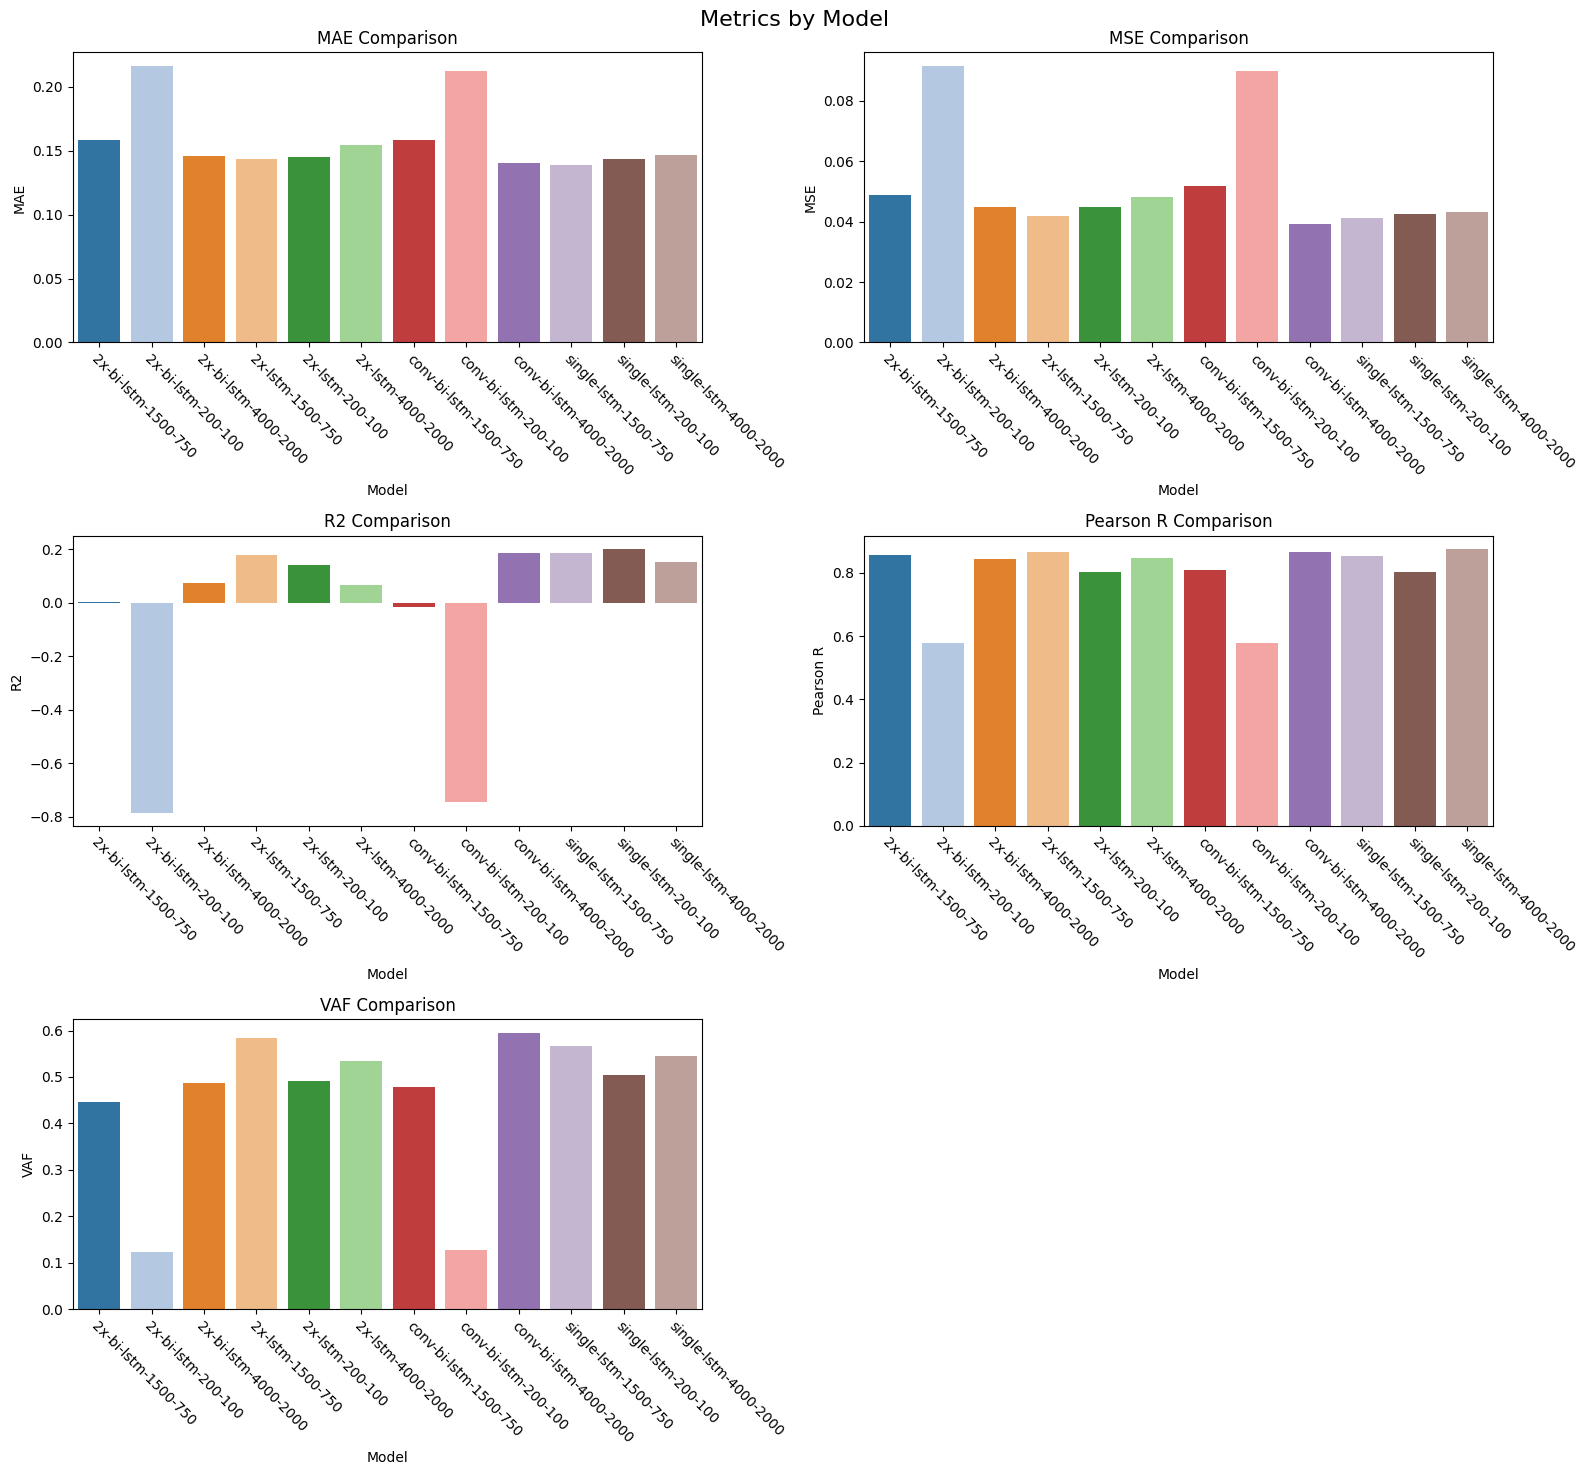

Metrics plot saved to prediction/out/metrics_by_mvc_level.png


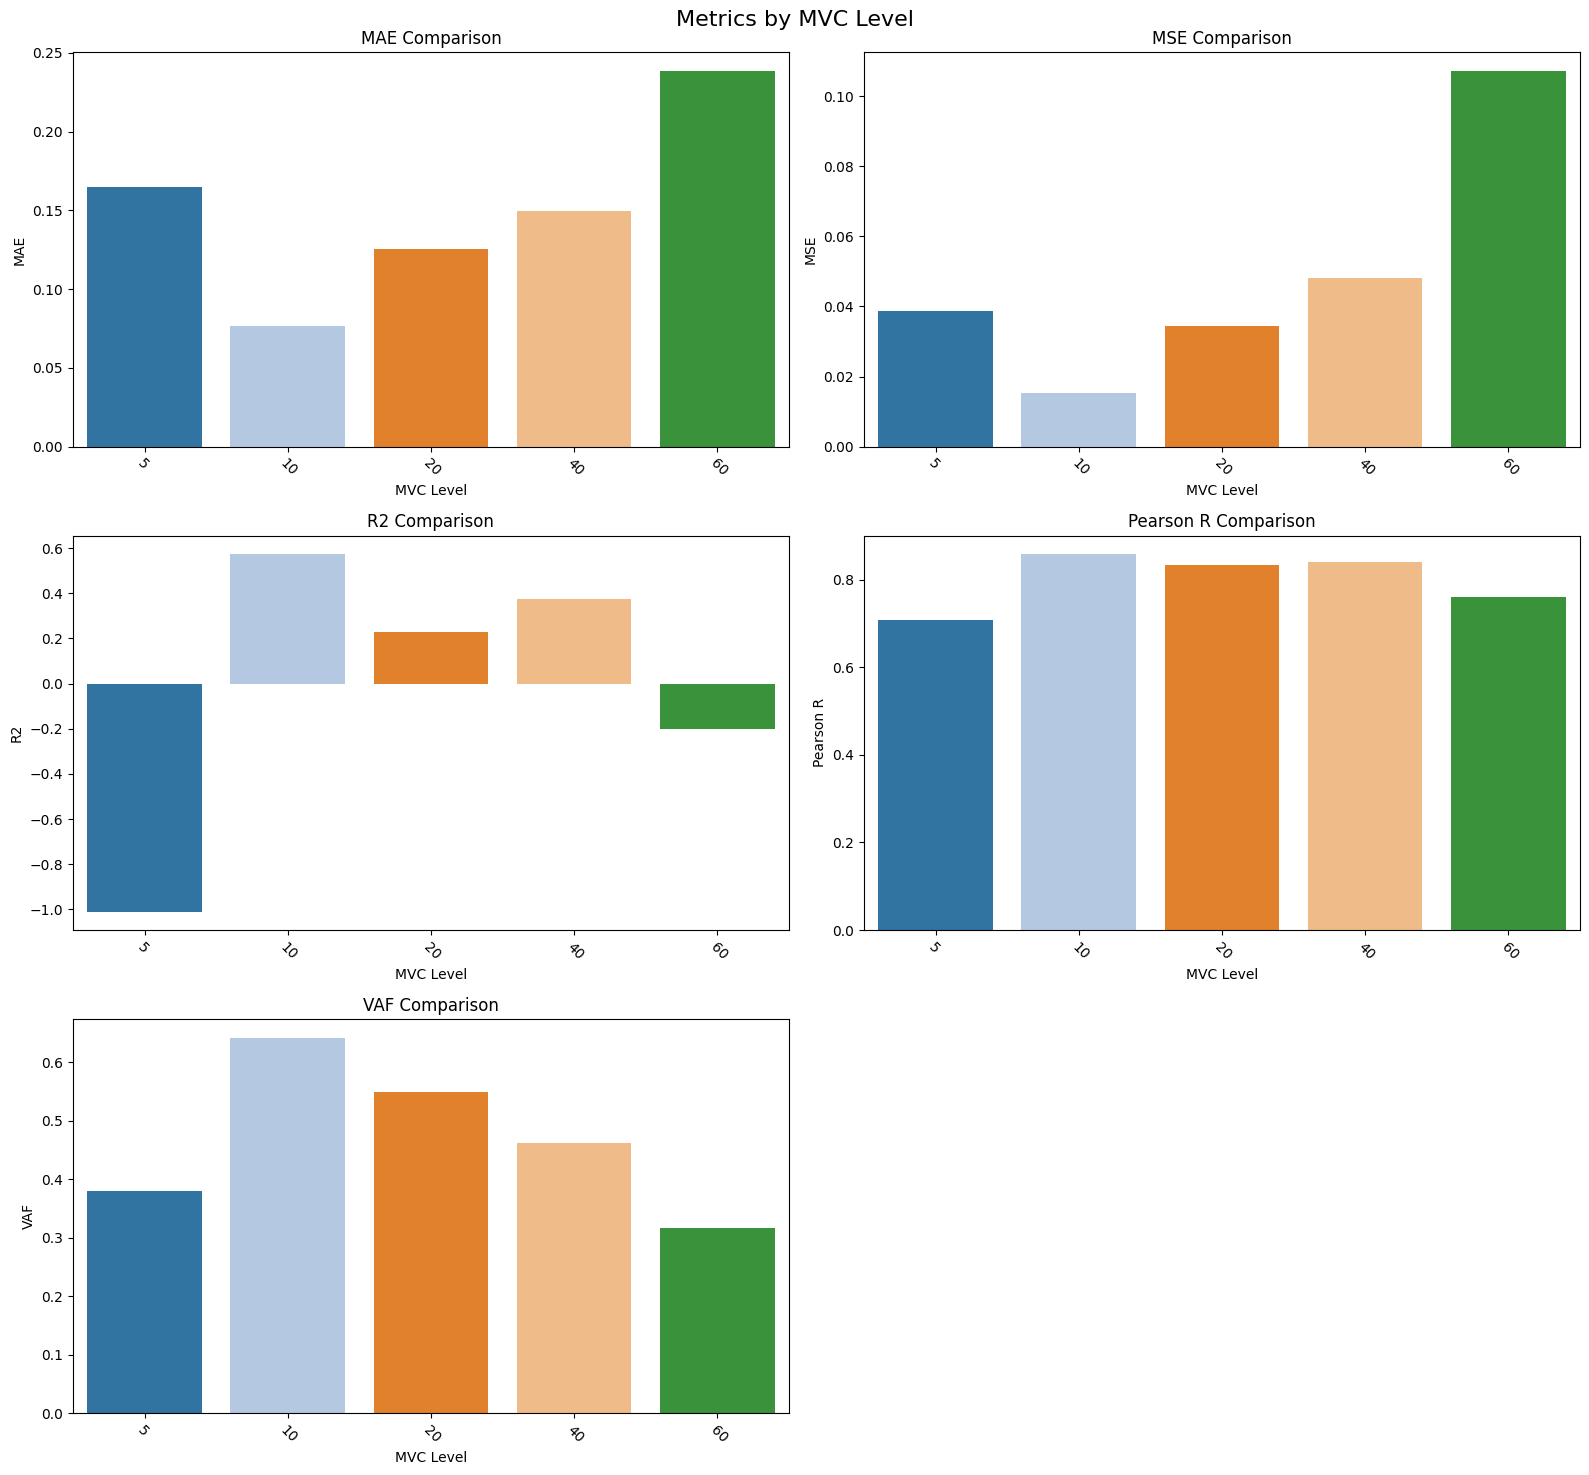

Metrics plot saved to prediction/out/metrics_by_window.png


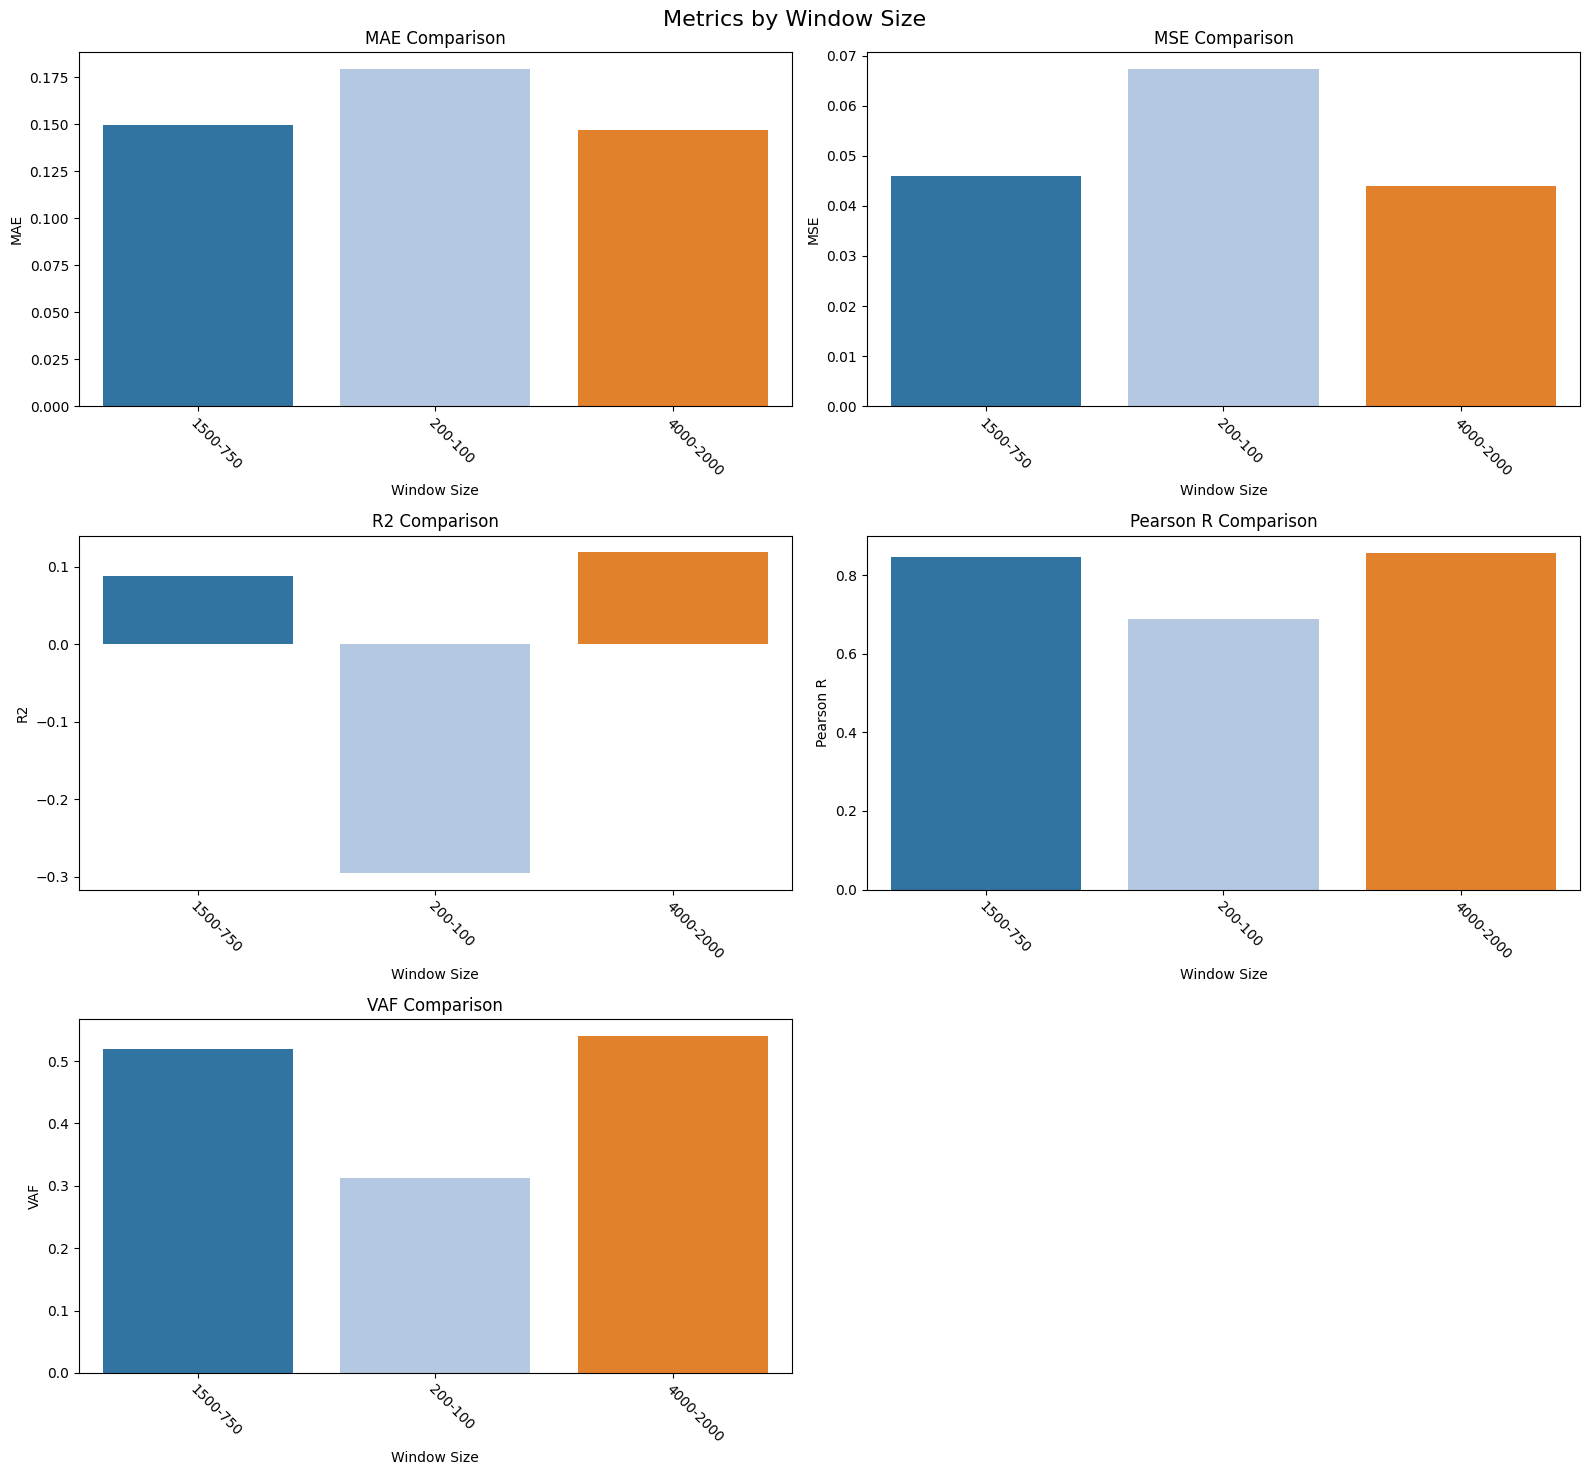

In [ ]:
metrics.visualize(export=False)

In [43]:
from prediction import constants
processor = processing.processing.Processing(df, **constants.architecture_temporal_context_windows['medium'])
model = prediction.dpm.DirectPredictionModel(processor=processor, architecture_name='2x-lstm', overwrite=False)

# subject_name = 'giannatos'
# mvc_level = 5
# trial_number = 2

subject_name = 'dwrotheos'
mvc_level = 10
trial_number = 1

# subject_name = 'giannatos'
# trial_number = 2

trial = df[(df['subject'] == subject_name) & (df['mvc_level'] == mvc_level) & (df['trial_number'] == trial_number)].iloc[0]

predicted_force = model.predict(trial['neuron_data'], trial['mvc_level'])

Loading existing model: 2x-lstm-1500-750
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 511ms/step


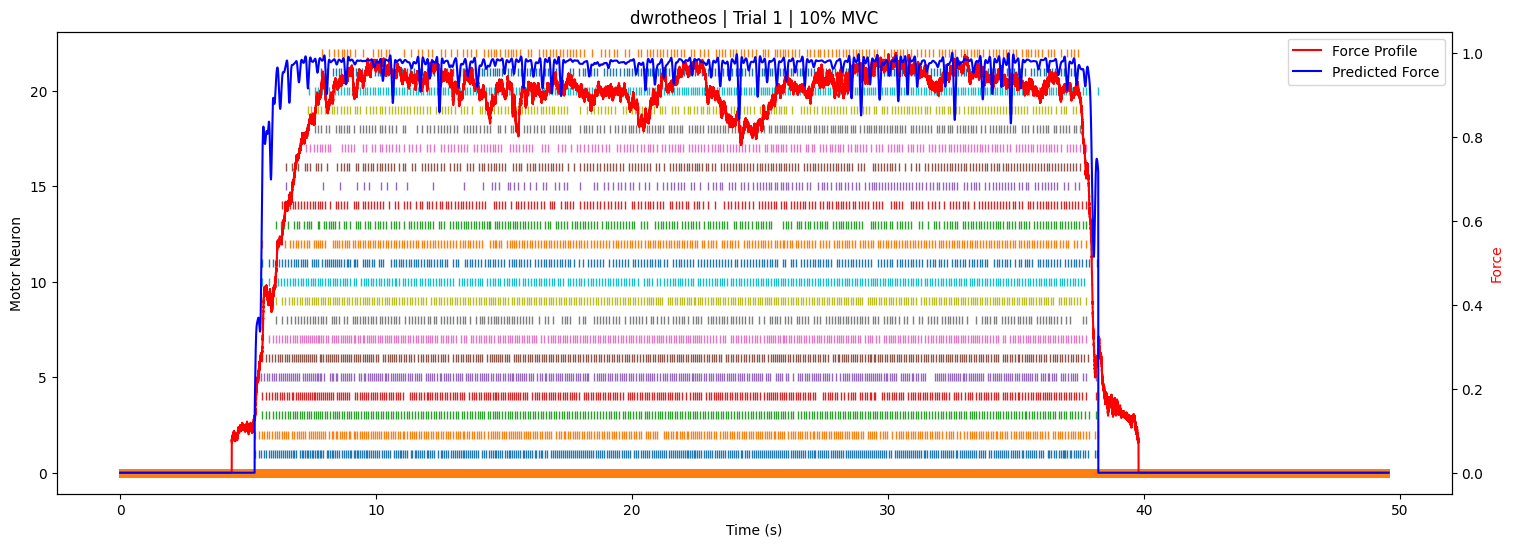

In [44]:
from globals.visualization import visualize_trial

visualize_trial(df, subject=trial['subject'], trial_number=trial['trial_number'], mvc_level=trial['mvc_level'], predicted_force=predicted_force)